# EduMind AI
## Adaptive Learning & Skill-Gap Detection Agent

### SDG 4 – Quality Education

EduMind AI is an AI-powered personalized learning system that analyzes
student performance, identifies knowledge gaps, recommends personalized
learning paths, provides AI-based explanations, and adapts quizzes
according to the learner's performance.

### Core Technologies
- Python
- Pandas
- NumPy
- Scikit-learn
- Generative AI
- Retrieval-Augmented Generation (RAG)
- Streamlit

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

print("EduMind AI environment initialized successfully!")

EduMind AI environment initialized successfully!


In [3]:
data = {
    "Student_ID": ["S001", "S002", "S003", "S004", "S005",
                   "S006", "S007", "S008", "S009", "S010"],

    "Python": [85, 72, 90, 65, 78, 92, 55, 81, 69, 88],

    "Statistics": [60, 75, 82, 55, 68, 90, 45, 72, 58, 80],

    "Probability": [35, 65, 70, 40, 52, 85, 30, 60, 45, 72],

    "Machine_Learning": [70, 68, 85, 50, 65, 88, 42, 75, 55, 80]
}

students = pd.DataFrame(data)

students

,Student_ID,Python,Statistics,Probability,Machine_Learning
0,S001,85,60,35,70
1,S002,72,75,65,68
2,S003,90,82,70,85
3,S004,65,55,40,50
4,S005,78,68,52,65
5,S006,92,90,85,88
6,S007,55,45,30,42
7,S008,81,72,60,75
8,S009,69,58,45,55
9,S010,88,80,72,80


In [4]:
subjects = ["Python", "Statistics", "Probability", "Machine_Learning"]

students["Overall_Score"] = students[subjects].mean(axis=1)

students

,Student_ID,Python,Statistics,Probability,Machine_Learning,Overall_Score
0,S001,85,60,35,70,62.50
1,S002,72,75,65,68,70.00
2,S003,90,82,70,85,81.75
3,S004,65,55,40,50,52.50
4,S005,78,68,52,65,65.75
5,S006,92,90,85,88,88.75
6,S007,55,45,30,42,43.00
7,S008,81,72,60,75,72.00
8,S009,69,58,45,55,56.75
9,S010,88,80,72,80,80.00


In [5]:
def classify_skill(score):
    if score < 50:
        return "Critical Gap"
    elif score < 70:
        return "Needs Improvement"
    elif score < 85:
        return "Good"
    else:
        return "Strong"


for subject in subjects:
    students[subject + "_Level"] = students[subject].apply(classify_skill)

students

,Student_ID,Python,Statistics,Probability,Machine_Learning,Overall_Score,Python_Level,Statistics_Level,Probability_Level,Machine_Learning_Level
0,S001,85,60,35,70,62.50,Strong,Needs Improvement,Critical Gap,Good
1,S002,72,75,65,68,70.00,Good,Good,Needs Improvement,Needs Improvement
2,S003,90,82,70,85,81.75,Strong,Good,Good,Strong
3,S004,65,55,40,50,52.50,Needs Improvement,Needs Improvement,Critical Gap,Needs Improvement
4,S005,78,68,52,65,65.75,Good,Needs Improvement,Needs Improvement,Needs Improvement
5,S006,92,90,85,88,88.75,Strong,Strong,Strong,Strong
6,S007,55,45,30,42,43.00,Needs Improvement,Critical Gap,Critical Gap,Critical Gap
7,S008,81,72,60,75,72.00,Good,Good,Needs Improvement,Good
8,S009,69,58,45,55,56.75,Needs Improvement,Needs Improvement,Critical Gap,Needs Improvement
9,S010,88,80,72,80,80.00,Strong,Good,Good,Good


In [6]:
student_id = "S001"

student = students[students["Student_ID"] == student_id].iloc[0]

print("Student:", student["Student_ID"])
print()

for subject in subjects:
    print(
        subject,
        ":", student[subject],
        "%",
        "→",
        student[subject + "_Level"]
    )

Student: S001

Python : 85 % → Strong
Statistics : 60 % → Needs Improvement
Probability : 35 % → Critical Gap
Machine_Learning : 70 % → Good


In [7]:
# STEP 10: Personalized Recommendation Engine

def generate_recommendation(student):
    skill_scores = {
        subject: student[subject]
        for subject in subjects
    }

    # Sort subjects from weakest to strongest
    sorted_skills = sorted(skill_scores.items(), key=lambda x: x[1])

    weakest_subject = sorted_skills[0][0]
    weakest_score = sorted_skills[0][1]

    if weakest_score < 50:
        priority = "High Priority"
        message = (
            f"You have a significant learning gap in {weakest_subject}. "
            f"Your current score is {weakest_score}%. "
            f"Focus on the fundamentals before moving to advanced topics."
        )

    elif weakest_score < 70:
        priority = "Medium Priority"
        message = (
            f"You need more practice in {weakest_subject}. "
            f"Your current score is {weakest_score}%. "
            f"Revise the concepts and take another assessment."
        )

    else:
        priority = "Low Priority"
        message = (
            f"Your lowest-performing area is {weakest_subject} "
            f"with {weakest_score}%. You can continue with advanced topics "
            f"while maintaining regular revision."
        )

    return weakest_subject, priority, message

In [8]:
weakest, priority, message = generate_recommendation(student)

print("======================================")
print("       EDUMIND AI RECOMMENDATION")
print("======================================")
print()
print("Student:", student["Student_ID"])
print("Recommended Topic:", weakest)
print("Priority:", priority)
print()
print("Recommendation:")
print(message)

       EDUMIND AI RECOMMENDATION

Student: S001
Recommended Topic: Probability
Priority: High Priority

Recommendation:
You have a significant learning gap in Probability. Your current score is 35%. Focus on the fundamentals before moving to advanced topics.


In [9]:
def create_learning_path(student):
    skill_scores = {
        subject: student[subject]
        for subject in subjects
    }

    sorted_skills = sorted(skill_scores.items(), key=lambda x: x[1])

    learning_path = []

    for subject, score in sorted_skills:

        if score < 50:
            action = "Learn fundamentals"
        elif score < 70:
            action = "Revise and practice"
        elif score < 85:
            action = "Practice advanced questions"
        else:
            action = "Explore advanced topics"

        learning_path.append({
            "Topic": subject,
            "Score": score,
            "Recommended_Action": action
        })

    return pd.DataFrame(learning_path)

In [10]:
learning_path = create_learning_path(student)

learning_path

,Topic,Score,Recommended_Action
0,Probability,35,Learn fundamentals
1,Statistics,60,Revise and practice
2,Machine_Learning,70,Practice advanced questions
3,Python,85,Explore advanced topics


In [11]:
def calculate_readiness(student):
    scores = [student[subject] for subject in subjects]
    average = np.mean(scores)

    # Convert average performance to a 0–100 readiness score
    readiness = round(average, 2)

    return readiness

In [12]:
readiness = calculate_readiness(student)

print("Student:", student["Student_ID"])
print("Learning Readiness Score:", readiness, "/ 100")

Student: S001
Learning Readiness Score: 62.5 / 100


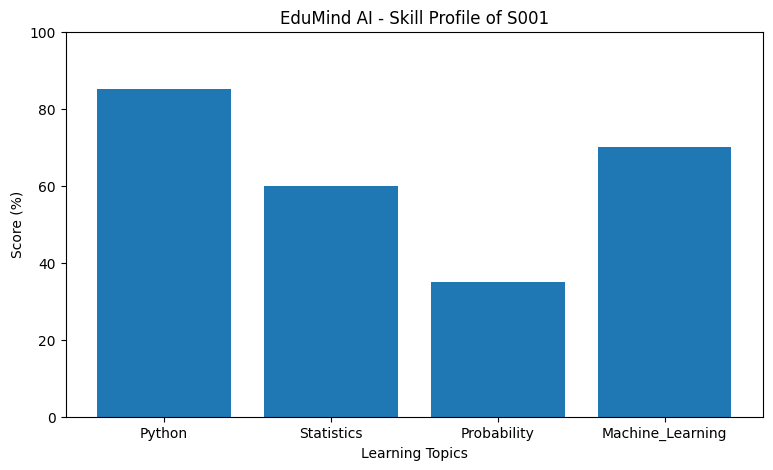

In [13]:
scores = [student[subject] for subject in subjects]

plt.figure(figsize=(9, 5))

plt.bar(subjects, scores)

plt.ylim(0, 100)
plt.xlabel("Learning Topics")
plt.ylabel("Score (%)")
plt.title(f"EduMind AI - Skill Profile of {student['Student_ID']}")

plt.show()

In [14]:
!pip install -q google-genai

In [15]:
from google import genai
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("AI Tutor connected successfully!")

AI Tutor connected successfully!


In [16]:
def ask_edumind(question, language="English"):

    prompt = f"""
You are EduMind AI, an intelligent and supportive educational tutor.

Student's question:
{question}

Preferred language:
{language}

Your responsibilities:
1. Explain the concept clearly from the basics.
2. Use simple and student-friendly language.
3. Give a practical example.
4. If the student asks for Telugu, explain naturally in Telugu.
5. Avoid unnecessary technical complexity.
6. End with one short question to check the student's understanding.

Answer:
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [18]:
def get_student_profile(student):

    profile = {}

    for subject in subjects:
        profile[subject] = {
            "score": student[subject],
            "level": student[subject + "_Level"]
        }

    return profile

In [19]:
student_profile = get_student_profile(student)

student_profile

{'Python': {'score': np.int64(85), 'level': 'Strong'},
 'Statistics': {'score': np.int64(60), 'level': 'Needs Improvement'},
 'Probability': {'score': np.int64(35), 'level': 'Critical Gap'},
 'Machine_Learning': {'score': np.int64(70), 'level': 'Good'}}

In [20]:
def personalized_tutor(question, student, language="English"):

    profile_text = ""

    for subject in subjects:
        profile_text += (
            f"{subject}: "
            f"{student[subject]}% "
            f"({student[subject + '_Level']})\n"
        )

    prompt = f"""
You are EduMind AI, a personalized educational tutor.

Student's learning profile:
{profile_text}

Student's question:
{question}

Preferred language:
{language}

Instructions:
- Adapt your explanation to the student's current knowledge.
- Pay extra attention to weak areas.
- Start from fundamentals when the student's score is low.
- Use a simple example.
- Do not overwhelm the student.
- If the language is Telugu, explain naturally in Telugu.
- End with one short practice question.

Provide the personalized explanation.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [22]:
!pip install -q pypdf faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 59.5 MB/s eta 0:00:00


In [23]:
import os
import faiss
import numpy as np

from pypdf import PdfReader

print("RAG libraries loaded successfully!")

RAG libraries loaded successfully!


In [24]:
from google.colab import files

uploaded = files.upload()

Saving L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55.pdf to L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55.pdf


In [25]:
pdf_filename = list(uploaded.keys())[0]

print("Uploaded file:", pdf_filename)

Uploaded file: L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55.pdf


In [26]:
reader = PdfReader(pdf_filename)

text = ""

for page in reader.pages:
    page_text = page.extract_text()

    if page_text:
        text += page_text + "\n"

print("Number of pages:", len(reader.pages))
print("Characters extracted:", len(text))

Number of pages: 26
Characters extracted: 9645


In [ ]:
print(text[:3000])

In [27]:

def create_chunks(text, chunk_size=1200, overlap=200):

    chunks = []

    start = 0

    while start < len(text):

        end = start + chunk_size

        chunk = text[start:end]

        if chunk.strip():
            chunks.append(chunk.strip())

        start += chunk_size - overlap

    return chunks

In [28]:
chunks = create_chunks(text)

print("Number of chunks:", len(chunks))

Number of chunks: 10


In [29]:
print(chunks[0])

Name Programme : B. Tech (CE-AI_DS)
Semester : 5
Subject Name and Code : Theory of Automata and Formal Language (01AI0505)
Unit No : 3
Unit Title : Finite State Machine
Unit-2 : Finite State Machine
i. Basics of Automata theory 
ii. Finite automata 
iii. Deterministic and Non-Deterministic Automata
iv. ^ - Transition Finite automata, 
v. Conversion NFA - ^ to NFA, 
vi. Conversion NFA to DFA, 
vii. Conversion RE(Regular Expression) to Non-Deterministic Finite Automata, 
viii. Subset Algorithm to convert Non DFA to DFA, 
ix. Finite automata minimization, 
x. Moore and Mealey machine and their Conversion.
Lecture 3: Moore and Mealy Machine
Session Outline:
Moore Machine
Mealy Machine
Learning Outcomes:
By the end of this session, Learners will be able to:
Define a Non-Deterministic Finite Automaton (NDFA) andexplain its basic components and working
principles.
Differentiate between Deterministic Finite Automata (DFA) and Non-Deterministic Finite Automata
(NDFA) based on their transition b

In [30]:
from google.genai import types

def create_embeddings(texts):

    result = client.models.embed_content(
        model="gemini-embedding-2",
        contents=texts,
        config=types.EmbedContentConfig(
            output_dimensionality=768
        )
    )

    return [embedding.values for embedding in result.embeddings]

In [31]:
embeddings = create_embeddings(chunks)

embeddings = np.array(embeddings).astype("float32")

print("Embedding shape:", embeddings.shape)

Embedding shape: (1, 768)


In [32]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("FAISS vector database created!")
print("Stored vectors:", index.ntotal)

FAISS vector database created!
Stored vectors: 1


In [33]:
def search_documents(query, top_k=3):

    query_embedding = create_embeddings([query])

    query_embedding = np.array(query_embedding).astype("float32")

    distances, indices = index.search(query_embedding, top_k)

    results = []

    for idx in indices[0]:

        if idx < len(chunks):
            results.append(chunks[idx])

    return results

In [34]:
query = "What is machine learning?"

results = search_documents(query, top_k=3)

for i, result in enumerate(results):
    print(f"\n--- Retrieved Chunk {i+1} ---\n")
    print(result[:1000])


--- Retrieved Chunk 1 ---

Name Programme : B. Tech (CE-AI_DS)
Semester : 5
Subject Name and Code : Theory of Automata and Formal Language (01AI0505)
Unit No : 3
Unit Title : Finite State Machine
Unit-2 : Finite State Machine
i. Basics of Automata theory 
ii. Finite automata 
iii. Deterministic and Non-Deterministic Automata
iv. ^ - Transition Finite automata, 
v. Conversion NFA - ^ to NFA, 
vi. Conversion NFA to DFA, 
vii. Conversion RE(Regular Expression) to Non-Deterministic Finite Automata, 
viii. Subset Algorithm to convert Non DFA to DFA, 
ix. Finite automata minimization, 
x. Moore and Mealey machine and their Conversion.
Lecture 3: Moore and Mealy Machine
Session Outline:
Moore Machine
Mealy Machine
Learning Outcomes:
By the end of this session, Learners will be able to:
Define a Non-Deterministic Finite Automaton (NDFA) andexplain its basic components and working
principles.
Differentiate between Deterministic Finite Automata (DFA) and Non-Deterministic Finite Automata
(NDFA)

In [35]:
def rag_answer(question):

    relevant_chunks = search_documents(question, top_k=3)

    context = "\n\n".join(relevant_chunks)

    prompt = f"""
You are EduMind AI, an educational assistant.

Answer the student's question using the study material provided below.

STUDY MATERIAL:
{context}

STUDENT QUESTION:
{question}

Instructions:
1. Use the study material as the primary source.
2. Explain clearly and simply.
3. Do not invent information that is not supported by the provided material.
4. If the answer is not available in the study material, clearly say that.
5. Give an example when useful.
"""

    response = client.models.generate_content(
        model="gemini-3.8-flash",
        contents=prompt
    )

    return response.text

In [36]:
def rag_answer(question):

    relevant_chunks = search_documents(question, top_k=3)

    context = "\n\n".join(relevant_chunks)

    prompt = f"""
You are EduMind AI, an educational assistant.

Answer the student's question using the study material provided below.

STUDY MATERIAL:
{context}

STUDENT QUESTION:
{question}

Instructions:
1. Use the study material as the primary source.
2. Explain clearly and simply.
3. Do not invent information that is not supported by the provided material.
4. If the answer is not available in the study material, clearly say that.
5. Give an example when useful.
"""

    response = client.models.generate_content(
        model="gemini-3.8-flash",
        contents=prompt
    )

    return response.text

In [37]:
answer = rag_answer(
    "Explain the difference between Moore and Mealy machines."
)

print(answer)

Based on the provided study material, the detailed differences between **Moore** and **Mealy machines** are not available. 

While the syllabus and session outline list **"Moore and Mealey machine and their Conversion"** and **"MEALY AND MOORE MODELS,"** the notes do not provide the definitions, working principles, or comparative points for these two machines. The detailed content in the text only covers the equivalence of DFA and NDFA and the subset construction method.


In [40]:
import json
import re
import time

def generate_ai_quiz(topic, difficulty="Medium", number_of_questions=5):

    retrieved_chunks = search_documents(topic, top_k=5)
    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
You are EduMind AI, a university-level quiz generator.

Generate {number_of_questions} multiple-choice questions.

TOPIC: {topic}
DIFFICULTY: {difficulty}

Use ONLY the following study material:

{context}

Requirements:
1. Generate exactly {number_of_questions} questions.
2. Each question must have four options: A, B, C, D.
3. Only one answer must be correct.
4. Provide a short explanation for each answer.
5. Do not invent facts unsupported by the material.
6. Return valid JSON only, without Markdown code fences.

Required JSON format:
{{
  "questions": [
    {{
      "question": "Question text",
      "options": {{
        "A": "Option A",
        "B": "Option B",
        "C": "Option C",
        "D": "Option D"
      }},
      "answer": "A",
      "explanation": "Explanation",
      "topic": "{topic}",
      "difficulty": "{difficulty}"
    }}
  ]
}}
"""

    for attempt in range(3):
        try:
            response = client.models.generate_content(
                model="gemini-3.8-flash",
                contents=prompt
            )

            raw_text = response.text.strip()

            raw_text = re.sub(
                r"^```(?:json)?\s*|\s*```$",
                "",
                raw_text
            )

            quiz_data = json.loads(raw_text)
            questions = quiz_data["questions"]

            if len(questions) != number_of_questions:
                raise ValueError(
                    f"Expected {number_of_questions} questions, "
                    f"received {len(questions)}."
                )

            for question in questions:
                if (
                    not all(
                        key in question
                        for key in [
                            "question",
                            "options",
                            "answer",
                            "explanation"
                        ]
                    )
                    or set(question["options"].keys())
                    != {"A", "B", "C", "D"}
                    or question["answer"] not in {"A", "B", "C", "D"}
                ):
                    raise ValueError("Invalid question format returned.")

            return questions

        except Exception as e:
            error_message = str(e)

            if attempt < 2 and (
                "503" in error_message
                or "UNAVAILABLE" in error_message
                or "429" in error_message
                or "RESOURCE_EXHAUSTED" in error_message
            ):
                wait_time = 2 ** (attempt + 1)
                print(
                    f"Gemini is temporarily busy. "
                    f"Retrying in {wait_time} seconds..."
                )
                time.sleep(wait_time)
            else:
                raise

    raise RuntimeError("Quiz generation failed after multiple attempts.")

In [42]:
quiz = generate_ai_quiz(
    topic="Moore and Mealy Machines",
    difficulty="Medium",
    number_of_questions=5
)

print("Quiz generated successfully!")
print("Total questions:", len(quiz))

Gemini is temporarily busy. Retrying in 2 seconds...
Quiz generated successfully!
Total questions: 5


In [43]:
for i, question in enumerate(quiz, start=1):

    print(f"\nQuestion {i}")
    print("-" * 50)

    print(question["question"])

    for option, text in question["options"].items():
        print(f"{option}. {text}")


Question 1
--------------------------------------------------
According to the provided material on the equivalence of DFA and NDFA, if a machine M has n states, how many states does the corresponding finite automaton have?
A. n^2 states
B. 2^n states
C. 2n states
D. n! states

Question 2
--------------------------------------------------
When constructing the transition function δ for the equivalent automaton M1 accepting T(M), which states must δ be constructed for?
A. All 2^n states regardless of reachability
B. Only states that are reachable from {q0}
C. Only the non-reachable states of M
D. Only the single final state {q1}

Question 3
--------------------------------------------------
According to the procedure described for the equivalence of DFA and NDFA, when does the construction of δ halt?
A. When all 2^n states have been fully defined
B. When the initial state {q0} is eliminated
C. When no more new states appear under the input columns
D. When the number of transitions reac

In [44]:
def take_ai_quiz(quiz):

    results = []
    correct_count = 0

    for i, question in enumerate(quiz, start=1):

        print(f"\nQuestion {i}")
        print("-" * 50)
        print(question["question"])

        for option, text in question["options"].items():
            print(f"{option}. {text}")

        answer = input("Your answer (A/B/C/D): ").strip().upper()

        while answer not in ["A", "B", "C", "D"]:
            answer = input("Enter A, B, C, or D: ").strip().upper()

        correct_answer = question["answer"].upper()
        is_correct = answer == correct_answer

        if is_correct:
            correct_count += 1
            print("Correct!")
        else:
            print("Incorrect!")
            print("Correct answer:", correct_answer)

        print("Explanation:", question["explanation"])

        results.append({
            "Question": question["question"],
            "Your_Answer": answer,
            "Correct_Answer": correct_answer,
            "Is_Correct": is_correct
        })

    score = round(correct_count / len(quiz) * 100, 2)

    return score, pd.DataFrame(results)

In [45]:
quiz_score, quiz_results = take_ai_quiz(quiz)

print("\n===== EDUMIND AI RESULTS =====")
print("Total questions:", len(quiz))
print("Score:", quiz_score, "%")

display(quiz_results)


Question 1
--------------------------------------------------
According to the provided material on the equivalence of DFA and NDFA, if a machine M has n states, how many states does the corresponding finite automaton have?
A. n^2 states
B. 2^n states
C. 2n states
D. n! states



KeyboardInterrupt



In [ ]:
def recommend_next_step(score, topic):

    if score < 50:
        return (
            f"Your performance in {topic} needs improvement. "
            "Review the fundamentals and take an easier quiz."
        )

    elif score < 80:
        return (
            f"You have a developing understanding of {topic}. "
            "Revise important concepts and practise more questions."
        )

    else:
        return (
            f"Good work! You performed well in {topic}. "
            "Try a harder quiz to test your understanding."
        )

In [1]:
def recommend_next_step(score, topic):

    if score < 50:
        return (
            f"Your performance in {topic} needs improvement. "
            "Review the fundamentals and take an easier quiz."
        )

    elif score < 80:
        return (
            f"You have a developing understanding of {topic}. "
            "Revise important concepts and practise more questions."
        )

    else:
        return (
            f"Good work! You performed well in {topic}. "
            "Try a harder quiz to test your understanding."
        )

print("Recommendation function is ready!")

Recommendation function is ready!


In [3]:
print("Quiz exists:", "quiz" in globals())
print("Quiz score exists:", "quiz_score" in globals())

Quiz exists: False
Quiz score exists: False


In [4]:
print("AI quiz function:", "generate_ai_quiz" in globals())
print("Document search function:", "search_documents" in globals())
print("Gemini client:", "client" in globals())

AI quiz function: False
Document search function: False
Gemini client: False


In [5]:
!pip install -q google-genai pypdf faiss-cpu pandas numpy

In [6]:
from google import genai
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")

if not api_key:
    raise ValueError(
        "GEMINI_API_KEY is missing. "
        "Add it in Colab Secrets and enable notebook access."
    )

client = genai.Client(api_key=api_key)

print("EduMind AI connected to Gemini!")

EduMind AI connected to Gemini!


In [7]:
import os

print("PDF filename available:", "pdf_filename" in globals())
print("PDF text available:", "text" in globals())

PDF filename available: False
PDF text available: False


In [8]:
from google.colab import files

uploaded = files.upload()

pdf_filename = next(iter(uploaded.keys()))

print("Uploaded:", pdf_filename)

Saving L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55.pdf to L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55 (1).pdf
Uploaded: L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55 (1).pdf


In [9]:
from pypdf import PdfReader

reader = PdfReader(pdf_filename)

text = "\n".join(
    page.extract_text() or ""
    for page in reader.pages
)

print("Pages:", len(reader.pages))
print("Characters extracted:", len(text))

Pages: 26
Characters extracted: 9645


In [10]:
import faiss
import numpy as np
from google.genai import types

def create_chunks(text, chunk_size=1200, overlap=200):
    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(text), step):
        chunk = text[start:start + chunk_size]

        if chunk.strip():
            chunks.append(chunk.strip())

    return chunks


chunks = create_chunks(text)

print("Document chunks:", len(chunks))

Document chunks: 10


In [11]:
def create_embeddings(texts):
    result = client.models.embed_content(
        model="gemini-embedding-2",
        contents=texts,
        config=types.EmbedContentConfig(
            output_dimensionality=768
        )
    )

    return [
        embedding.values
        for embedding in result.embeddings
    ]


embeddings = np.array(
    create_embeddings(chunks),
    dtype="float32"
)

print("Embedding shape:", embeddings.shape)

Embedding shape: (1, 768)


In [12]:
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

print("FAISS index restored:", index.ntotal, "vectors")

FAISS index restored: 1 vectors


In [13]:
def search_documents(query, top_k=3):

    query_embedding = np.array(
        create_embeddings([query]),
        dtype="float32"
    )

    k = min(top_k, index.ntotal)

    distances, indices = index.search(
        query_embedding,
        k
    )

    return [
        chunks[i]
        for i in indices[0]
        if 0 <= i < len(chunks)
    ]


print(search_documents("What is a Moore machine?")[0][:500])

Name Programme : B. Tech (CE-AI_DS)
Semester : 5
Subject Name and Code : Theory of Automata and Formal Language (01AI0505)
Unit No : 3
Unit Title : Finite State Machine
Unit-2 : Finite State Machine
i. Basics of Automata theory 
ii. Finite automata 
iii. Deterministic and Non-Deterministic Automata
iv. ^ - Transition Finite automata, 
v. Conversion NFA - ^ to NFA, 
vi. Conversion NFA to DFA, 
vii. Conversion RE(Regular Expression) to Non-Deterministic Finite Automata, 
viii. Subset Algorithm to 


In [14]:
import os
import faiss
import numpy as np

from pypdf import PdfReader
from google.genai import types

print("Required libraries imported successfully!")

Required libraries imported successfully!


In [15]:
from google.colab import files

uploaded = files.upload()

pdf_filename = next(iter(uploaded.keys()))

reader = PdfReader(pdf_filename)

text = "\n".join(
    page.extract_text() or ""
    for page in reader.pages
)

print("Pages:", len(reader.pages))
print("Characters extracted:", len(text))

Saving L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55 (1).pdf to L4_MOORE_MEALY_U3pdf__2026_09_08_10_53_55 (1) (1).pdf
Pages: 26
Characters extracted: 9645


In [16]:
def create_chunks(text, chunk_size=1200, overlap=200):

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(text), step):

        chunk = text[start:start + chunk_size]

        if chunk.strip():
            chunks.append(chunk.strip())

    return chunks


chunks = create_chunks(text)

print("Total document chunks:", len(chunks))

Total document chunks: 10


In [17]:
def create_embeddings(texts):

    result = client.models.embed_content(
        model="gemini-embedding-2",
        contents=texts,
        config=types.EmbedContentConfig(
            output_dimensionality=768
        )
    )

    return [
        embedding.values
        for embedding in result.embeddings
    ]


embeddings = np.array(
    create_embeddings(chunks),
    dtype="float32"
)

print("Embedding shape:", embeddings.shape)

Embedding shape: (1, 768)


In [18]:
index = faiss.IndexFlatL2(
    embeddings.shape[1]
)

index.add(embeddings)

print("FAISS database restored!")
print("Stored vectors:", index.ntotal)

FAISS database restored!
Stored vectors: 1


In [19]:
def search_documents(query, top_k=3):

    query_embedding = np.array(
        create_embeddings([query]),
        dtype="float32"
    )

    k = min(top_k, index.ntotal)

    distances, indices = index.search(
        query_embedding,
        k
    )

    return [
        chunks[i]
        for i in indices[0]
        if 0 <= i < len(chunks)
    ]

In [20]:
results = search_documents(
    "What is a Moore machine?",
    top_k=3
)

for result in results:
    print(result[:500])
    print("-" * 50)

Name Programme : B. Tech (CE-AI_DS)
Semester : 5
Subject Name and Code : Theory of Automata and Formal Language (01AI0505)
Unit No : 3
Unit Title : Finite State Machine
Unit-2 : Finite State Machine
i. Basics of Automata theory 
ii. Finite automata 
iii. Deterministic and Non-Deterministic Automata
iv. ^ - Transition Finite automata, 
v. Conversion NFA - ^ to NFA, 
vi. Conversion NFA to DFA, 
vii. Conversion RE(Regular Expression) to Non-Deterministic Finite Automata, 
viii. Subset Algorithm to 
--------------------------------------------------


In [21]:
import json
import re
import time

def generate_ai_quiz(topic, difficulty="Medium", number_of_questions=5):

    # Retrieve relevant content from your uploaded PDF
    retrieved_chunks = search_documents(topic, top_k=5)

    if not retrieved_chunks:
        raise ValueError("No relevant content found in the PDF.")

    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
You are EduMind AI, a university-level quiz generator.

Generate exactly {number_of_questions} MCQs.

Topic: {topic}
Difficulty: {difficulty}

Use only this study material:
{context}

Requirements:
- Four options per question: A, B, C, D.
- Only one correct answer.
- Include a short explanation.
- Questions must be supported by the study material.
- Return valid JSON only.

Format:
{{
  "questions": [
    {{
      "question": "Question text",
      "options": {{
        "A": "Option A",
        "B": "Option B",
        "C": "Option C",
        "D": "Option D"
      }},
      "answer": "A",
      "explanation": "Explanation"
    }}
  ]
}}
"""

    for attempt in range(3):

        try:
            response = client.models.generate_content(
                model="gemini-3.8-flash",
                contents=prompt
            )

            raw_text = response.text.strip()

            raw_text = re.sub(
                r"^```(?:json)?\s*|\s*```$",
                "",
                raw_text
            )

            quiz_data = json.loads(raw_text)
            questions = quiz_data["questions"]

            if len(questions) != number_of_questions:
                raise ValueError(
                    f"Expected {number_of_questions} questions, "
                    f"received {len(questions)}."
                )

            return questions

        except Exception as e:

            error_message = str(e)

            if attempt < 2 and (
                "503" in error_message
                or "429" in error_message
                or "UNAVAILABLE" in error_message
                or "RESOURCE_EXHAUSTED" in error_message
            ):
                wait_time = 2 ** (attempt + 1)

                print(
                    f"Temporary API issue. "
                    f"Retrying in {wait_time} seconds..."
                )

                time.sleep(wait_time)

            else:
                raise

In [22]:
quiz = generate_ai_quiz(
    topic="Moore and Mealy Machines",
    difficulty="Medium",
    number_of_questions=5
)

print("EduMind AI Quiz Generated!")
print("Total Questions:", len(quiz))

EduMind AI Quiz Generated!
Total Questions: 5


In [23]:
for i, question in enumerate(quiz, start=1):

    print(f"\nQuestion {i}")
    print("-" * 50)

    print(question["question"])

    for option, option_text in question["options"].items():
        print(f"{option}. {option_text}")


Question 1
--------------------------------------------------
According to the course syllabus outline for Finite State Machines, which specific study or operation is paired with Moore and Mealy machines?
A. Minimization algorithm
B. Subset construction
C. Their Conversion
D. Regular Expression derivation

Question 2
--------------------------------------------------
In the provided syllabus for Theory of Automata and Formal Language, which lecture is dedicated to 'Moore and Mealy Machine'?
A. Lecture 1
B. Lecture 2
C. Lecture 3
D. Lecture 4

Question 3
--------------------------------------------------
What are the two topics explicitly listed in the Session Outline for Lecture 3?
A. Moore Machine and Mealy Machine
B. DFA and NDFA
C. NFA to DFA Conversion and Minimization
D. Basics of Automata and Finite Automata

Question 4
--------------------------------------------------
Under which Unit Title are the Moore and Mealy models categorized in this course?
A. Turing Machines
B. Finite

In [24]:
import pandas as pd

def take_ai_quiz(quiz):

    results = []
    correct_count = 0

    for i, question in enumerate(quiz, start=1):

        print(f"\nQuestion {i}")
        print("-" * 50)
        print(question["question"])

        for option, option_text in question["options"].items():
            print(f"{option}. {option_text}")

        while True:
            answer = input("Your answer (A/B/C/D): ").strip().upper()

            if answer in ["A", "B", "C", "D"]:
                break

            print("Please enter A, B, C, or D.")

        correct_answer = question["answer"].strip().upper()
        is_correct = answer == correct_answer

        if is_correct:
            correct_count += 1
            print("Correct!")
        else:
            print("Incorrect!")
            print("Correct answer:", correct_answer)

        print("Explanation:", question["explanation"])

        results.append({
            "Question": question["question"],
            "Your_Answer": answer,
            "Correct_Answer": correct_answer,
            "Is_Correct": is_correct
        })

    score = round((correct_count / len(quiz)) * 100, 2) if quiz else 0

    return score, pd.DataFrame(results)


print("Quiz evaluation system created successfully!")

Quiz evaluation system created successfully!


In [26]:
quiz_score, quiz_results = take_ai_quiz(quiz)


Question 1
--------------------------------------------------
According to the course syllabus outline for Finite State Machines, which specific study or operation is paired with Moore and Mealy machines?
A. Minimization algorithm
B. Subset construction
C. Their Conversion
D. Regular Expression derivation
Your answer (A/B/C/D): A
Incorrect!
Correct answer: C
Explanation: Topic (x) in the unit syllabus explicitly lists 'Moore and Mealey machine and their Conversion.'

Question 2
--------------------------------------------------
In the provided syllabus for Theory of Automata and Formal Language, which lecture is dedicated to 'Moore and Mealy Machine'?
A. Lecture 1
B. Lecture 2
C. Lecture 3
D. Lecture 4
Your answer (A/B/C/D): B
Incorrect!
Correct answer: C
Explanation: The material specifies 'Lecture 3: Moore and Mealy Machine'.

Question 3
--------------------------------------------------
What are the two topics explicitly listed in the Session Outline for Lecture 3?
A. Moore Machine

In [27]:
print("=" * 45)
print("       EDUMIND AI QUIZ RESULTS")
print("=" * 45)

print("Total Questions:", len(quiz))
print("Correct Answers:", int(quiz_results["Is_Correct"].sum()))
print("Final Score:", quiz_score, "%")

if quiz_score < 50:
    print("Performance: Needs Improvement")
elif quiz_score < 80:
    print("Performance: Good Progress")
else:
    print("Performance: Excellent")

display(quiz_results)

       EDUMIND AI QUIZ RESULTS
Total Questions: 5
Correct Answers: 0
Final Score: 0.0 %
Performance: Needs Improvement


,Question,Your_Answer,Correct_Answer,Is_Correct
0,According to the course syllabus outline for F...,A,C,False
1,In the provided syllabus for Theory of Automat...,B,C,False
2,What are the two topics explicitly listed in t...,C,A,False
3,Under which Unit Title are the Moore and Mealy...,D,B,False
4,"According to the unit syllabus, which topic im...",B,D,False


In [28]:
def recommend_next_step(score, topic):

    if score < 50:
        return (
            f"Revise the fundamentals of {topic} "
            "and practise easier questions."
        )

    elif score < 80:
        return (
            f"Revise important concepts in {topic} "
            "and practise more questions."
        )

    else:
        return (
            f"Excellent progress in {topic}! "
            "Try more challenging questions."
        )


recommendation = recommend_next_step(
    quiz_score,
    "Moore and Mealy Machines"
)

print("YOUR PERSONALIZED LEARNING PLAN")
print(recommendation)

YOUR PERSONALIZED LEARNING PLAN
Revise the fundamentals of Moore and Mealy Machines and practise easier questions.


In [29]:
print("Total Questions:", len(quiz))
print("Correct Answers:", int(quiz_results["Is_Correct"].sum()))
print("Quiz Score:", quiz_score, "%")

display(quiz_results)

Total Questions: 5
Correct Answers: 0
Quiz Score: 0.0 %


,Question,Your_Answer,Correct_Answer,Is_Correct
0,According to the course syllabus outline for F...,A,C,False
1,In the provided syllabus for Theory of Automat...,B,C,False
2,What are the two topics explicitly listed in t...,C,A,False
3,Under which Unit Title are the Moore and Mealy...,D,B,False
4,"According to the unit syllabus, which topic im...",B,D,False


In [30]:
for i, question in enumerate(quiz, start=1):
    print(f"\nQuestion {i}:")
    print(question["question"])
    print("Correct Answer:", question["answer"])
    print("Explanation:", question["explanation"])


Question 1:
According to the course syllabus outline for Finite State Machines, which specific study or operation is paired with Moore and Mealy machines?
Correct Answer: C
Explanation: Topic (x) in the unit syllabus explicitly lists 'Moore and Mealey machine and their Conversion.'

Question 2:
In the provided syllabus for Theory of Automata and Formal Language, which lecture is dedicated to 'Moore and Mealy Machine'?
Correct Answer: C
Explanation: The material specifies 'Lecture 3: Moore and Mealy Machine'.

Question 3:
What are the two topics explicitly listed in the Session Outline for Lecture 3?
Correct Answer: A
Explanation: Under Lecture 3: Moore and Mealy Machine, the Session Outline lists 'Moore Machine' and 'Mealy Machine'.

Question 4:
Under which Unit Title are the Moore and Mealy models categorized in this course?
Correct Answer: B
Explanation: The unit covering Moore and Mealy machines is titled 'Finite State Machine'.

Question 5:
According to the unit syllabus, which to

In [31]:
def personalized_learning_recommendation(score, topic="Finite State Machines"):

    print("🎓 EduMind AI - Personalized Learning Report")
    print("=" * 50)
    print(f"📚 Topic: {topic}")
    print(f"📊 Quiz Score: {score}%")
    print()

    if score < 40:
        print("📌 Performance: Needs Improvement")
        print("💡 Recommendation: Start with the basic concepts.")
        print("📝 Action Plan:")
        print("1. Study the definitions and fundamentals.")
        print("2. Learn the difference between Moore and Mealy machines.")
        print("3. Review your study material.")
        print("4. Take another easy quiz.")

    elif score < 70:
        print("📌 Performance: Average")
        print("💡 Recommendation: Strengthen your understanding.")
        print("📝 Action Plan:")
        print("1. Revise important concepts.")
        print("2. Practise identifying machine components.")
        print("3. Solve medium-difficulty questions.")
        print("4. Retake the quiz.")

    elif score < 90:
        print("📌 Performance: Good")
        print("💡 Recommendation: Practise application-based questions.")
        print("📝 Action Plan:")
        print("1. Practise Moore and Mealy machine conversions.")
        print("2. Study DFA and NDFA equivalence.")
        print("3. Solve challenging questions.")
        print("4. Attempt a difficult quiz.")

    else:
        print("📌 Performance: Excellent!")
        print("💡 Recommendation: You have demonstrated strong quiz performance.")
        print("📝 Action Plan:")
        print("1. Practise advanced conversion problems.")
        print("2. Solve application-based questions.")
        print("3. Explain the concepts in your own words.")

    print("\n✅ Goal: Improve your understanding through targeted practice.")


# Generate a recommendation using your quiz score
personalized_learning_recommendation(
    score=quiz_score,
    topic="Finite State Machines"
)

🎓 EduMind AI - Personalized Learning Report
📚 Topic: Finite State Machines
📊 Quiz Score: 0.0%

📌 Performance: Needs Improvement
💡 Recommendation: Start with the basic concepts.
📝 Action Plan:
1. Study the definitions and fundamentals.
2. Learn the difference between Moore and Mealy machines.
3. Review your study material.
4. Take another easy quiz.

✅ Goal: Improve your understanding through targeted practice.


In [32]:
import pandas as pd

def detect_weak_topics(quiz_results, quiz):
    topic_performance = {}

    for i, question in enumerate(quiz):
        topic = question.get("topic", "Finite State Machines")
        is_correct = bool(quiz_results.iloc[i]["Is_Correct"])

        if topic not in topic_performance:
            topic_performance[topic] = {
                "Correct": 0,
                "Total": 0
            }

        topic_performance[topic]["Total"] += 1

        if is_correct:
            topic_performance[topic]["Correct"] += 1

    report = []

    for topic, data in topic_performance.items():
        total = data["Total"]
        correct = data["Correct"]
        accuracy = round((correct / total) * 100, 2)

        if accuracy < 50:
            status = "Needs Improvement"
        elif accuracy < 80:
            status = "Practice More"
        else:
            status = "Good"

        report.append({
            "Topic": topic,
            "Correct Answers": correct,
            "Total Questions": total,
            "Accuracy (%)": accuracy,
            "Status": status
        })

    return pd.DataFrame(report)


# Generate your weak-topic report
weak_topic_report = detect_weak_topics(quiz_results, quiz)

display(weak_topic_report)

,Topic,Correct Answers,Total Questions,Accuracy (%),Status
0,Finite State Machines,0,5,0.0,Needs Improvement


In [33]:
def adaptive_quiz(previous_score, topic="Finite State Machines", number_of_questions=5):

    if previous_score < 40:
        difficulty = "Easy"
    elif previous_score < 70:
        difficulty = "Medium"
    elif previous_score < 90:
        difficulty = "Hard"
    else:
        difficulty = "Advanced"

    print("🎓 EduMind AI - Adaptive Quiz")
    print("=" * 40)
    print("Previous Score:", previous_score, "%")
    print("Selected Difficulty:", difficulty)
    print("Topic:", topic)

    new_quiz = generate_ai_quiz(
        topic=topic,
        difficulty=difficulty,
        number_of_questions=number_of_questions
    )

    return new_quiz


print("Adaptive quiz function created successfully!")

Adaptive quiz function created successfully!


In [39]:
adaptive_quiz_questions = adaptive_quiz(
    previous_score=quiz_score,
    topic="Moore and Mealy Machines",
    number_of_questions=5
)

for i, question in enumerate(adaptive_quiz_questions, start=1):
    print(f"\nQuestion {i}: {question['question']}")
    for option, answer in question["options"].items():
        print(f"{option}. {answer}")

🎓 EduMind AI - Adaptive Quiz
Previous Score: 0.0 %
Selected Difficulty: Easy
Topic: Moore and Mealy Machines
Temporary API issue. Retrying in 2 seconds...
Temporary API issue. Retrying in 4 seconds...


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [36]:
import pandas as pd
from datetime import datetime

# Store student quiz history
if "student_progress" not in globals():
    student_progress = pd.DataFrame(
        columns=[
            "Date",
            "Topic",
            "Difficulty",
            "Score (%)",
            "Performance"
        ]
    )


def track_progress(topic, score, difficulty="Medium"):

    global student_progress

    if score < 40:
        performance = "Needs Improvement"
    elif score < 70:
        performance = "Average"
    elif score < 90:
        performance = "Good"
    else:
        performance = "Excellent"

    new_record = pd.DataFrame([{
        "Date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Topic": topic,
        "Difficulty": difficulty,
        "Score (%)": score,
        "Performance": performance
    }])

    student_progress = pd.concat(
        [student_progress, new_record],
        ignore_index=True
    )

    print("✅ Progress recorded successfully!")


print("EduMind AI Progress Tracker is ready!")

EduMind AI Progress Tracker is ready!


In [37]:
track_progress(
    topic="Moore and Mealy Machines",
    score=quiz_score,
    difficulty="Medium"
)

display(student_progress)

✅ Progress recorded successfully!


/tmp/ipykernel_12223/1474155709.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  student_progress = pd.concat(


,Date,Topic,Difficulty,Score (%),Performance
0,2026-10-09 07:38,Moore and Mealy Machines,Medium,0.0,Needs Improvement


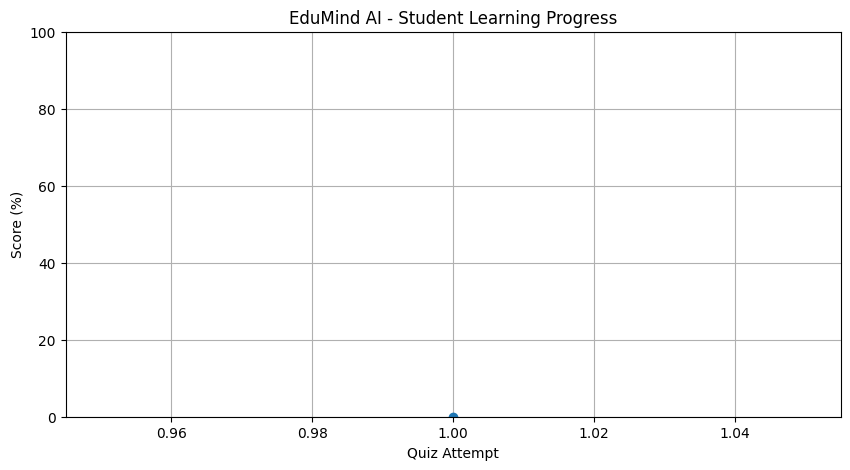

In [38]:
import matplotlib.pyplot as plt

if not student_progress.empty:

    plt.figure(figsize=(10, 5))

    plt.plot(
        range(1, len(student_progress) + 1),
        student_progress["Score (%)"].astype(float),
        marker="o"
    )

    plt.title("EduMind AI - Student Learning Progress")
    plt.xlabel("Quiz Attempt")
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()

else:
    print("No quiz records available yet.")

In [40]:
import pandas as pd
from IPython.display import display, Markdown

def show_student_dashboard():

    display(Markdown("# 🎓 EduMind AI — Student Dashboard"))
    display(Markdown("### Adaptive Learning & Skill-Gap Detection Agent"))

    print("\n📊 OVERALL PERFORMANCE")
    print("-" * 40)

    if "student_progress" not in globals() or student_progress.empty:
        print("No progress records found. Complete a quiz first.")
    else:
        scores = pd.to_numeric(
            student_progress["Score (%)"],
            errors="coerce"
        ).dropna()

        if not scores.empty:
            print("Total Quiz Attempts:", len(scores))
            print("Average Score:", round(scores.mean(), 2), "%")
            print("Best Score:", round(scores.max(), 2), "%")
            print("Latest Score:", round(scores.iloc[-1], 2), "%")

            print("\n📚 TOPIC-WISE PROGRESS")
            display(
                student_progress[
                    ["Topic", "Difficulty", "Score (%)", "Performance"]
                ]
            )

            if len(scores) >= 2:
                improvement = scores.iloc[-1] - scores.iloc[0]
                print("\n📈 Score Change:", round(improvement, 2), "percentage points")

    print("\n🤖 LEARNING ASSISTANT")
    print("Complete quizzes regularly to identify weak areas")
    print("and receive more targeted learning recommendations.")


show_student_dashboard()

# 🎓 EduMind AI — Student Dashboard

### Adaptive Learning & Skill-Gap Detection Agent


📊 OVERALL PERFORMANCE
----------------------------------------
Total Quiz Attempts: 1
Average Score: 0.0 %
Best Score: 0.0 %
Latest Score: 0.0 %

📚 TOPIC-WISE PROGRESS


,Topic,Difficulty,Score (%),Performance
0,Moore and Mealy Machines,Medium,0.0,Needs Improvement



🤖 LEARNING ASSISTANT
Complete quizzes regularly to identify weak areas
and receive more targeted learning recommendations.


In [41]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.6 MB/s eta 0:00:00


In [42]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="EduMind AI",
    page_icon="🎓",
    layout="wide"
)

st.title("🎓 EduMind AI")
st.subheader("Adaptive Learning & Skill-Gap Detection Agent")

st.markdown("""
Welcome to EduMind AI!

Your AI-powered learning assistant helps students:

- 📚 Learn from study materials
- 🤖 Ask questions about concepts
- 📝 Practise AI-generated quizzes
- 🎯 Identify learning gaps
- 📊 Track academic progress
""")

st.divider()

page = st.sidebar.selectbox(
    "Navigate",
    [
        "Home",
        "AI Tutor",
        "Adaptive Quiz",
        "Learning Recommendations",
        "Progress Dashboard"
    ]
)

if page == "Home":
    st.header("Welcome to your learning dashboard!")
    st.info("Select a feature from the sidebar to get started.")

elif page == "AI Tutor":
    st.header("🤖 AI Tutor")
    question = st.text_input("Ask a question about your subject")

    if st.button("Ask AI"):
        if question.strip():
            st.info(
                "AI Tutor interface is ready. "
                "Next, we will connect your Gemini API and RAG functions."
            )
        else:
            st.warning("Please enter a question.")

elif page == "Adaptive Quiz":
    st.header("📝 Adaptive Quiz")

    topic = st.text_input(
        "Enter a topic",
        value="Finite State Machines"
    )

    difficulty = st.selectbox(
        "Select difficulty",
        ["Easy", "Medium", "Hard", "Advanced"]
    )

    if st.button("Generate Quiz"):
        st.info(
            f"Quiz interface ready for {topic} at {difficulty} difficulty. "
            "Next, we will connect your existing quiz generator."
        )

elif page == "Learning Recommendations":
    st.header("🎯 Learning Recommendations")

    score = st.slider("Enter your latest quiz score", 0, 100, 50)

    if st.button("Get Recommendation"):
        if score < 40:
            st.warning("Revise the fundamentals and practise easy questions.")
        elif score < 70:
            st.info("Review difficult concepts and practise medium questions.")
        elif score < 90:
            st.success("Practise application-based and challenging questions.")
        else:
            st.balloons()
            st.success("Excellent! Try advanced questions and revision.")

elif page == "Progress Dashboard":
    st.header("📊 Student Progress Dashboard")
    st.info(
        "Progress visualization will be connected to persistent storage "
        "in a later step."
    )

st.divider()
st.caption("EduMind AI | SDG 4: Quality Education")

Writing app.py
